# Imports

In [80]:
import time
import pandas as pd
import numpy as np
import ast
import glob
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.image import imread
import nltk
from nltk import corpus, tokenize, stem
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, MiniBatchKMeans

import cv2 as cv


In [81]:
init_time = time.time()

# Chargement de données

In [82]:
!tree

.
├── classification.ipynb
├── data
│   └── Flipkart
│       ├── cleaned_data.csv
│       ├── flipkart_com-ecommerce_sample_1050.csv
│       └── Images
│           ├── 009099b1f6e1e8f893ec29a7023153c4.jpg
│           ├── 0096e89cc25a8b96fb9808716406fe94.jpg
│           ├── 00cbbc837d340fa163d11e169fbdb952.jpg
│           ├── 00d84a518e0550612fcfcba3b02b6255.jpg
│           ├── 00e966a5049a262cfc72e6bbf68b80e7.jpg
│           ├── 00ed03657cedbe4663eff2d7fa702a33.jpg
│           ├── 01089dc3618a0ab7304d784ef400b83d.jpg
│           ├── 0131e5d87b72877702d536299cf83b75.jpg
│           ├── 020d2daba55a723128e4e07c0b0393a9.jpg
│           ├── 02127f52e96fb72c66bf081d25104ef8.jpg
│           ├── 025a85a3d1cddc6307f7dc075d8d2132.jpg
│           ├── 02a53d335775b652f22f41b529b9d646.jpg
│           ├── 02c63a087b298ec74042d557acf61be1.jpg
│           ├── 031c98cfde349d99fb6d5983f54c8751.jpg
│           ├── 032e812adcd11a38fd8b764891a852ff.jpg
│           ├── 037b39bef3db7ccd264c577a0edf0c0a.jpg


In [83]:
#path = "/content/drive/MyDrive/data/Flipkart/"
path = "./data/Flipkart/"

In [84]:
data = pd.read_csv(path+'flipkart_com-ecommerce_sample_1050.csv')

# Analyse exploraoire & pretraitement des données

In [85]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('brown')
stop_words = set(corpus.stopwords.words('english'))

wordnet_map = {"N":corpus.wordnet.NOUN, "V":corpus.wordnet.VERB, "J":corpus.wordnet.ADJ, "R":corpus.wordnet.ADV}

def tokenize_document(document):
    # Transformer le document en lowercase
    document = document.lower().strip()

    # Tokeniser le document
    tokens = tokenize.word_tokenize(document)

    # Supprimer les stop-words
    tokens = [token for token in tokens if token not in stop_words]

    # Suprimer les token ayant moins de trois lettre
    tokens = [token for token in tokens if len(token) > 2]

    # Supprimer les caractéres non alpha numerique
    tokens = [token for token in tokens if token.isalpha()]

    return tokens


def stemming_document(tokenized_doc):

    stemmer = nltk.PorterStemmer()

    stems = [stemmer.stem(t) for t in tokenized_doc]

    return stems




train_sents = corpus.brown.tagged_sents(categories='news')
t0 = nltk.DefaultTagger('NN')
t1 = nltk.UnigramTagger(train_sents, backoff=t0)
t2 = nltk.BigramTagger(train_sents, backoff=t1)

def pos_tag_wordnet(text, pos_tag_type="pos_tag"):
    """
        Create pos_tag with wordnet format
    """
    pos_tagged_text = t2.tag(text)

    pos_tagged_text = [(word, wordnet_map.get(pos_tag[0])) if pos_tag[0] in wordnet_map.keys() else (word, corpus.wordnet.NOUN) for (word, pos_tag) in pos_tagged_text ]
    return pos_tagged_text


def lemmatize_word(text):
    """
        Lemmatize the tokenized words
    """

    lemmatizer = stem.WordNetLemmatizer()
    lemma = [lemmatizer.lemmatize(word, tag) for word, tag in text]
    return lemma

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/amadousy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amadousy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/amadousy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package brown to /home/amadousy/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [86]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [87]:
data.tail()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
1045,958f54f4c46b53c8a0a9b8167d9140bc,2015-12-01 10:15:43 +0000,http://www.flipkart.com/oren-empower-extra-lar...,Oren Empower Extra Large Self Adhesive Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE88ZGTX65GH4V,1399.0,999.0,958f54f4c46b53c8a0a9b8167d9140bc.jpg,False,Oren Empower Extra Large Self Adhesive Sticker...,No rating available,No rating available,Oren Empower,"{""product_specification""=>[{""key""=>""Number of ..."
1046,fd6cbcc22efb6b761bd564c28928483c,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-large-vinyl...,Wallmantra Large Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZD5GDCVQ,4930.0,1896.0,fd6cbcc22efb6b761bd564c28928483c.jpg,False,Wallmantra Large Vinyl Sticker Sticker (Pack o...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1047,5912e037d12774bb73a2048f35a00009,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-extra-large-p...,Uberlyfe Extra Large Pigmented Polyvinyl Films...,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE5UVGW2JWVWCT,4500.0,1449.0,5912e037d12774bb73a2048f35a00009.jpg,False,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,No rating available,No rating available,Uberlyfe,"{""product_specification""=>[{""key""=>""Number of ..."
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-medium-viny...,Wallmantra Medium Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZGFD3RCE,3465.0,1333.0,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg,False,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1049,f2f027ad6a6df617c9f125173da71e44,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-large-vinyl-s...,Uberlyfe Large Vinyl Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE2ZEPACRQJKH7,1190.0,595.0,f2f027ad6a6df617c9f125173da71e44.jpg,False,Buy Uberlyfe Large Vinyl Sticker for Rs.595 on...,4,4,Uberlyfe,"{""product_specification""=>[{""key""=>""Sales Pack..."


In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  1050 non-null   object 
 1   crawl_timestamp          1050 non-null   object 
 2   product_url              1050 non-null   object 
 3   product_name             1050 non-null   object 
 4   product_category_tree    1050 non-null   object 
 5   pid                      1050 non-null   object 
 6   retail_price             1049 non-null   float64
 7   discounted_price         1049 non-null   float64
 8   image                    1050 non-null   object 
 9   is_FK_Advantage_product  1050 non-null   bool   
 10  description              1050 non-null   object 
 11  product_rating           1050 non-null   object 
 12  overall_rating           1050 non-null   object 
 13  brand                    712 non-null    object 
 14  product_specifications  

In [89]:
data.dtypes.value_counts()

object     12
float64     2
bool        1
Name: count, dtype: int64

In [90]:
data.nunique()

uniq_id                    1050
crawl_timestamp             149
product_url                1050
product_name               1050
product_category_tree       642
pid                        1050
retail_price                354
discounted_price            424
image                      1050
is_FK_Advantage_product       2
description                1050
product_rating               27
overall_rating               27
brand                       490
product_specifications      984
dtype: int64

## | Documents manquants et/ou dupliqués

In [91]:
data.isna().sum()

uniq_id                      0
crawl_timestamp              0
product_url                  0
product_name                 0
product_category_tree        0
pid                          0
retail_price                 1
discounted_price             1
image                        0
is_FK_Advantage_product      0
description                  0
product_rating               0
overall_rating               0
brand                      338
product_specifications       1
dtype: int64

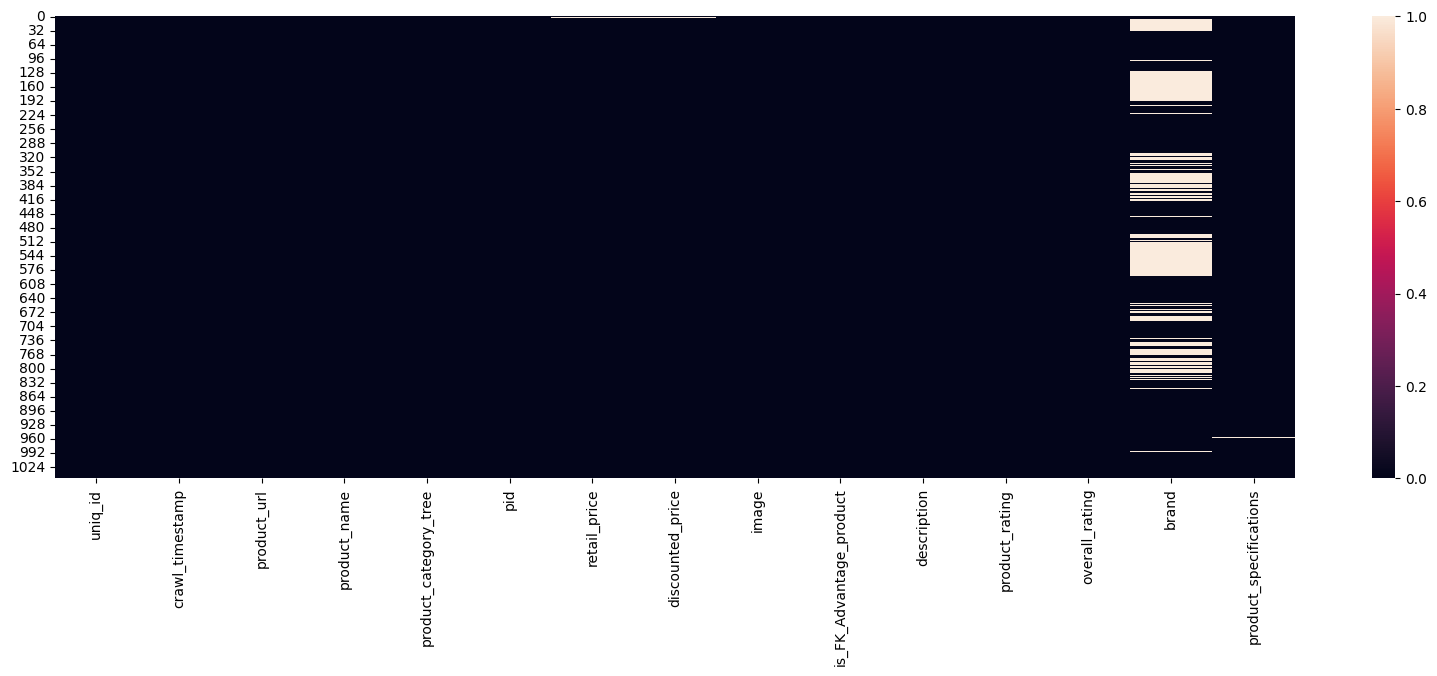

In [92]:
fig, _ = plt.subplots(1, 1, figsize=(20, 6))
sns.heatmap(data.isna())
plt.show()

In [93]:
data.duplicated(subset='uniq_id').sum()

np.int64(0)

## | variable: product_category_tree

In [94]:
data.product_category_tree.describe()

count                                                  1050
unique                                                  642
top       ["Home Furnishing >> Bed Linen >> Blankets, Qu...
freq                                                     56
Name: product_category_tree, dtype: object

In [95]:
data.product_category_tree[0]

'["Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do..."]'

On observe que la variable product_category_tree contient une liste de ctégorie pour chaque produit.

Nous allons explorer les categories.

In [96]:
def get_len_category(doc):
    doc = doc.replace('[', '').replace(']', '').strip('"')
    categories = doc.split(">>")
    categories = [cat.strip() for cat in categories]
    return len(set(categories))


def get_categorie(doc):
    doc = doc.replace('[', '').replace(']', '').strip('"')
    categories = doc.split(">>")
    categories = [cat.strip() for cat in categories]
    return categories[0]


tmp = data.product_category_tree.apply(get_len_category)

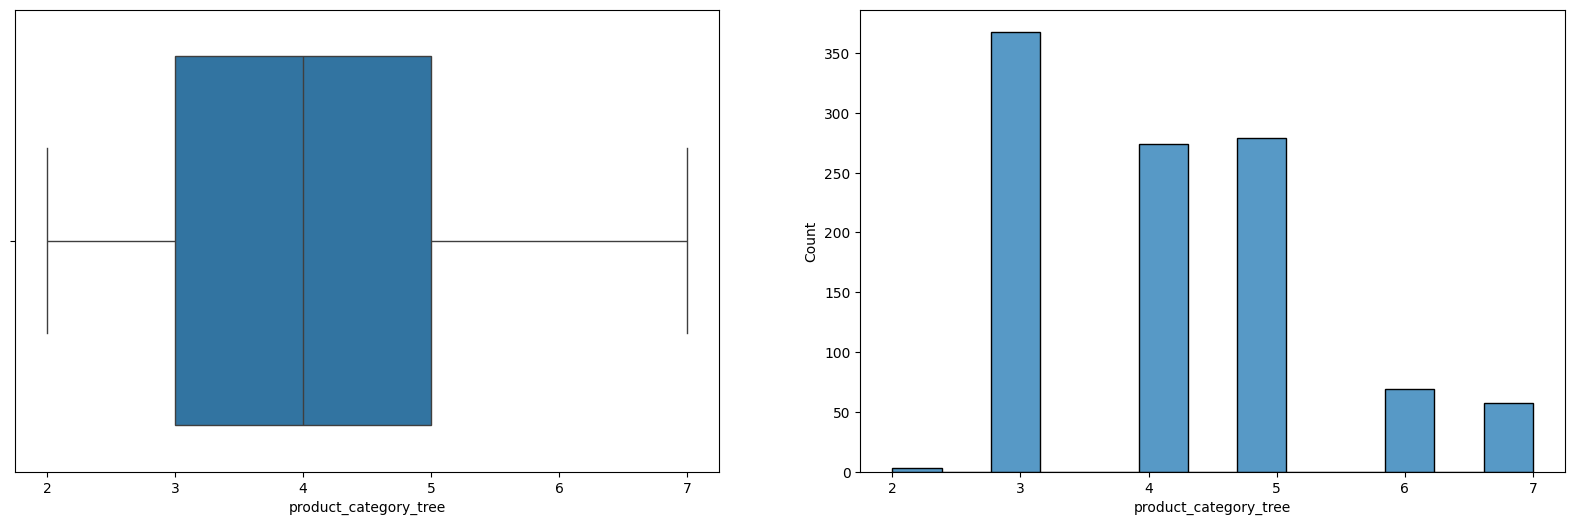

In [97]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 6))
sns.boxplot(x=tmp, ax=ax0)
sns.histplot(tmp, ax=ax1)
plt.show()

In [98]:
tmp.describe()

count    1050.000000
mean        4.203810
std         1.157058
min         2.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: product_category_tree, dtype: float64

Un produit à au minimum deux categories et au plus 7

In [99]:
tmp.value_counts()

product_category_tree
3    368
5    279
4    274
6     69
7     57
2      3
Name: count, dtype: int64

In [100]:
data['category'] = data['product_category_tree'].str.extract('([a-zA-Z ]+)', expand=False).str.strip()

In [101]:
data.category.value_counts()

category
Home Furnishing             150
Baby Care                   150
Watches                     150
Home Decor                  150
Kitchen                     150
Beauty and Personal Care    150
Computers                   150
Name: count, dtype: int64

In [102]:
p = data.loc[data.category == 'Home Furnishing', ]
p.iloc[0]['uniq_id']

'55b85ea15a1536d46b7190ad6fff8ce7'

Category: Home Furnishing


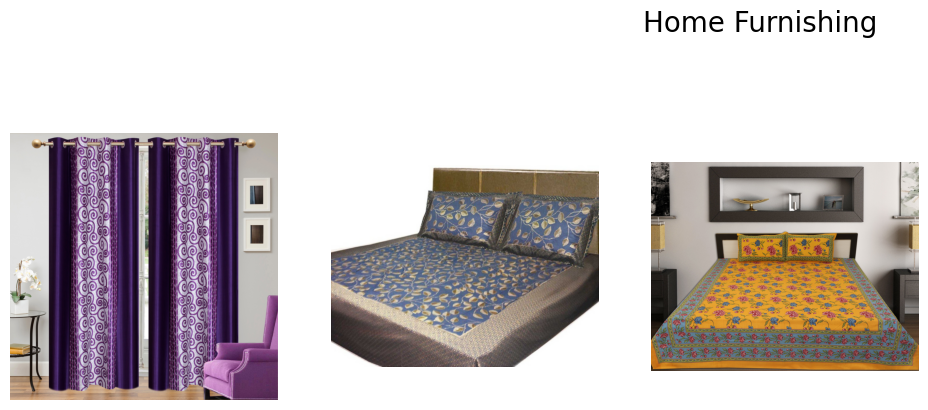

Category: Baby Care


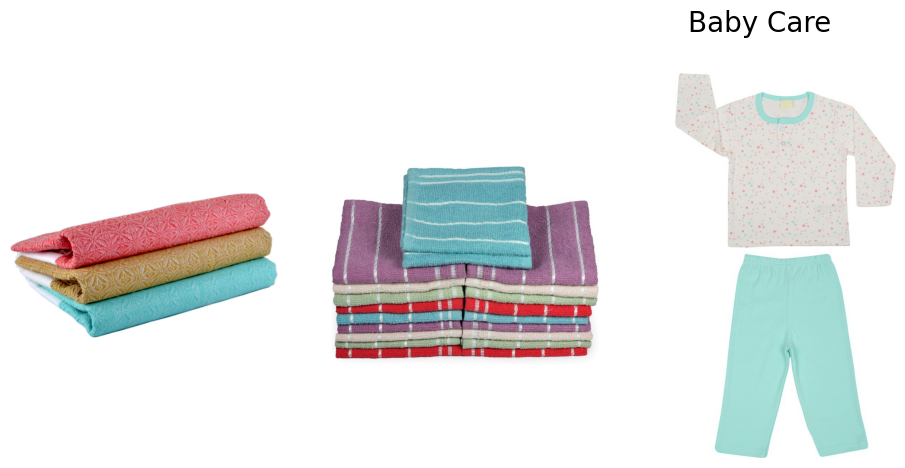

Category: Watches


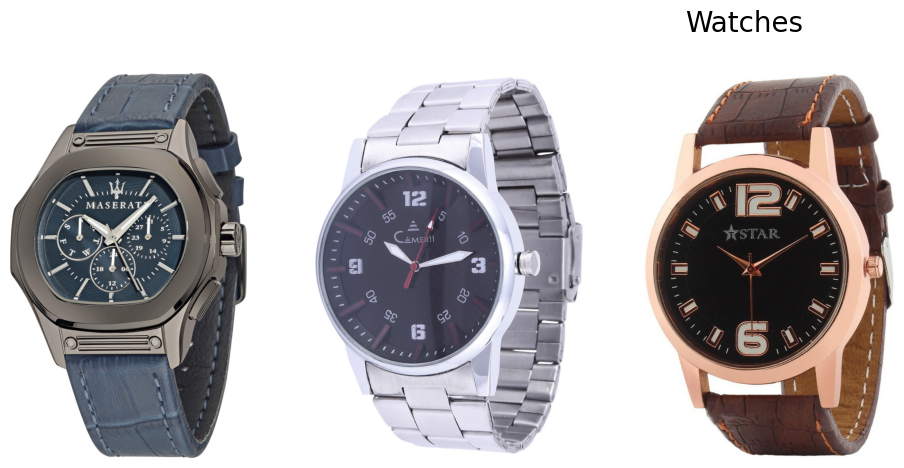

Category: Home Decor


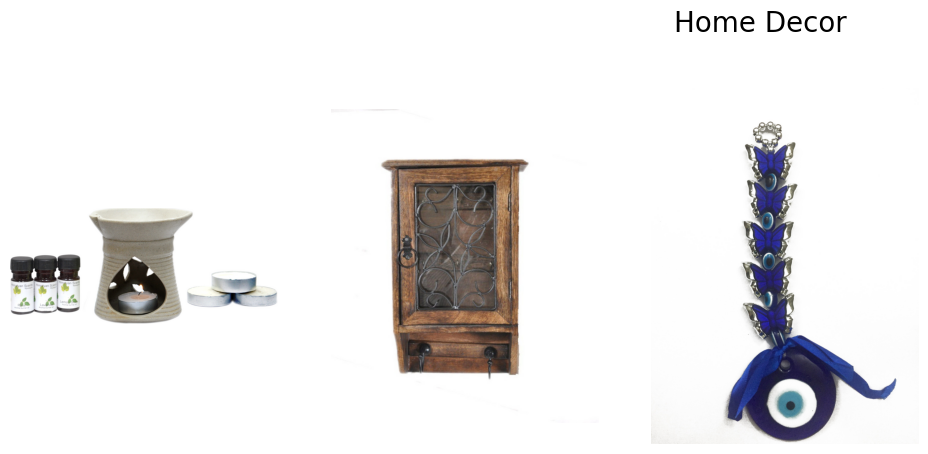

Category: Kitchen


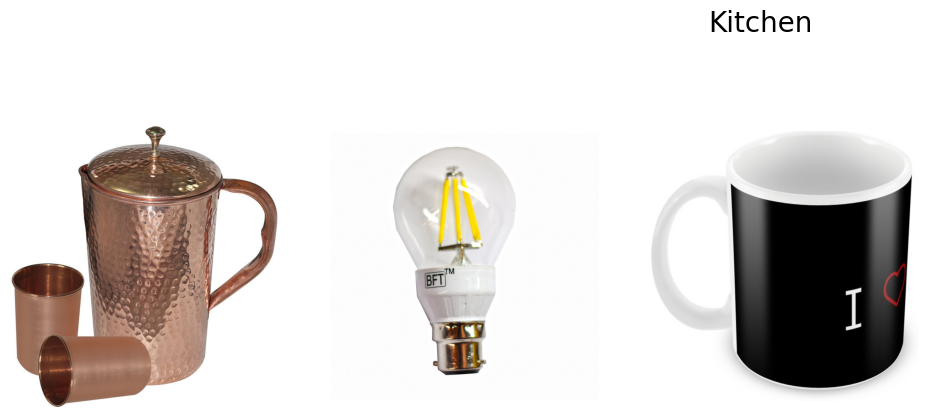

Category: Beauty and Personal Care


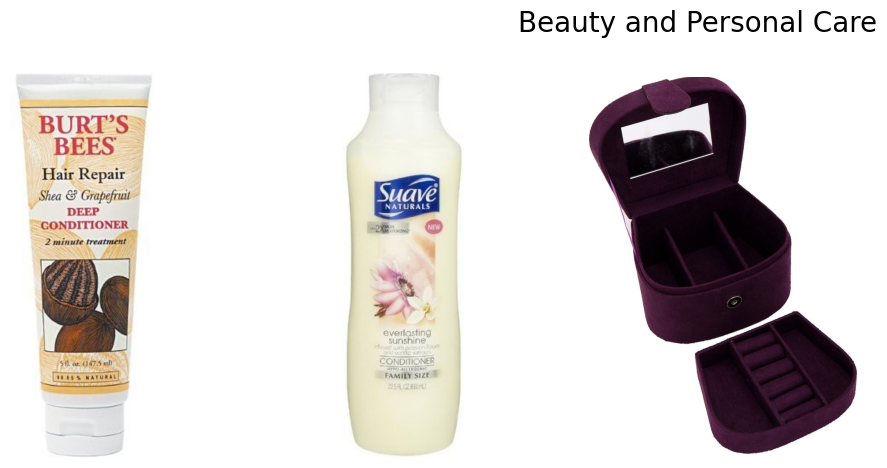

Category: Computers


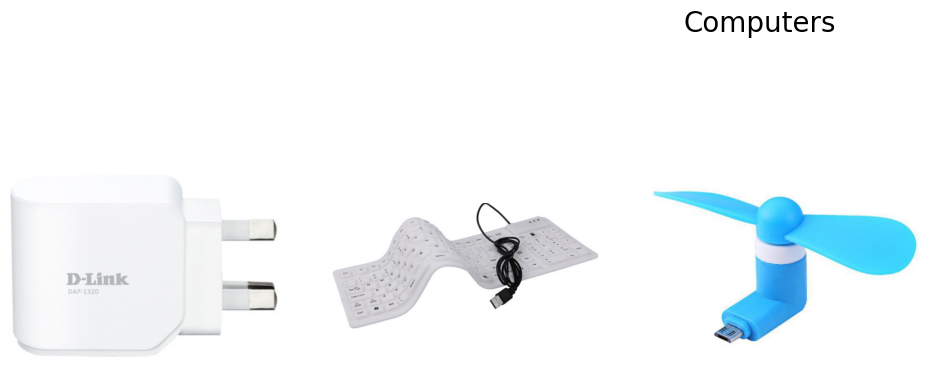

CPU times: user 12.1 s, sys: 958 ms, total: 13.1 s
Wall time: 12.6 s


In [103]:
%%time
# Affichage image de categorie
for i, category in enumerate(data.category.unique()):
    products = data.loc[data.category == category, ]
    fig = plt.figure(figsize = (20, 5))
    fig.suptitle(category, fontsize=20, va='center')
    for j in range(3):
        p = products.iloc[j]
        plt.subplot(150 + 1 + j)
        filename = path+"Images/"+p['uniq_id']+".jpg"
        image = imread(filename)
        plt.imshow(image)
        plt.axis('off')
    print(f"Category: {category}")
    #plt.suptitle(category, x=0.5, y=0.5)
    plt.show()

## | variable: description

In [104]:
data.head(5)

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,category
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v...",Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa...",Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",...",Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v...",Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa...",Home Furnishing


In [105]:
data.description.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1050 entries, 0 to 1049
Series name: description
Non-Null Count  Dtype 
--------------  ----- 
1050 non-null   object
dtypes: object(1)
memory usage: 8.3+ KB


In [106]:
data.description.describe()

count                                                  1050
unique                                                 1050
top       Buy Uberlyfe Large Vinyl Sticker for Rs.595 on...
freq                                                      1
Name: description, dtype: object

### Tokenization

In [107]:
data['tokenized_description'] = data.description.apply(tokenize_document)

In [108]:
data.tokenized_description

0       [key, features, elegance, polyester, multicolo...
1       [specifications, sathiyas, cotton, bath, towel...
2       [key, features, eurospa, cotton, terry, face, ...
3       [key, features, santosh, royal, fashion, cotto...
4       [key, features, jaipur, print, cotton, floral,...
                              ...                        
1045    [oren, empower, extra, large, self, adhesive, ...
1046    [wallmantra, large, vinyl, sticker, sticker, p...
1047    [buy, uberlyfe, extra, large, pigmented, polyv...
1048    [buy, wallmantra, medium, vinyl, sticker, stic...
1049    [buy, uberlyfe, large, vinyl, sticker, online,...
Name: tokenized_description, Length: 1050, dtype: object

### Stemming

In [109]:
data['stemmed_description'] = data.tokenized_description.apply(stemming_document)

In [110]:
data.stemmed_description

0       [key, featur, eleg, polyest, multicolor, abstr...
1       [specif, sathiya, cotton, bath, towel, bath, t...
2       [key, featur, eurospa, cotton, terri, face, to...
3       [key, featur, santosh, royal, fashion, cotton,...
4       [key, featur, jaipur, print, cotton, floral, k...
                              ...                        
1045    [oren, empow, extra, larg, self, adhes, sticke...
1046    [wallmantra, larg, vinyl, sticker, sticker, pa...
1047    [buy, uberlyf, extra, larg, pigment, polyvinyl...
1048    [buy, wallmantra, medium, vinyl, sticker, stic...
1049    [buy, uberlyf, larg, vinyl, sticker, onlin, ub...
Name: stemmed_description, Length: 1050, dtype: object

### Part of Speech Tagging (POS Tagging)

In [111]:
pos_tag_wordnet(data.tokenized_description[2])[:10]

[('key', 'n'),
 ('features', 'v'),
 ('eurospa', 'n'),
 ('cotton', 'n'),
 ('terry', 'n'),
 ('face', 'v'),
 ('towel', 'n'),
 ('set', 'v'),
 ('size', 'n'),
 ('small', 'a')]

In [112]:
data['combined_postag_wnet'] = data.tokenized_description.apply(lambda x: pos_tag_wordnet(x))

In [113]:
data.combined_postag_wnet

0       [(key, n), (features, v), (elegance, n), (poly...
1       [(specifications, n), (sathiyas, n), (cotton, ...
2       [(key, n), (features, v), (eurospa, n), (cotto...
3       [(key, n), (features, v), (santosh, n), (royal...
4       [(key, n), (features, v), (jaipur, n), (print,...
                              ...                        
1045    [(oren, n), (empower, n), (extra, a), (large, ...
1046    [(wallmantra, n), (large, a), (vinyl, n), (sti...
1047    [(buy, v), (uberlyfe, n), (extra, a), (large, ...
1048    [(buy, v), (wallmantra, n), (medium, n), (viny...
1049    [(buy, v), (uberlyfe, n), (large, a), (vinyl, ...
Name: combined_postag_wnet, Length: 1050, dtype: object

### Lemmatization

In [114]:
data['lemmatized_description'] = data.combined_postag_wnet.apply(lemmatize_word)
data['lemmatized_description_text'] = [' '.join(map(str, l)) for l in data['lemmatized_description']]

In [115]:
data['lemmatized_description_text']

0       key feature elegance polyester multicolor abst...
1       specification sathiyas cotton bath towel bath ...
2       key feature eurospa cotton terry face towel se...
3       key feature santosh royal fashion cotton print...
4       key feature jaipur print cotton floral king si...
                              ...                        
1045    oren empower extra large self adhesive sticker...
1046    wallmantra large vinyl sticker sticker pack pr...
1047    buy uberlyfe extra large pigmented polyvinyl f...
1048    buy wallmantra medium vinyl sticker sticker on...
1049    buy uberlyfe large vinyl sticker online uberly...
Name: lemmatized_description_text, Length: 1050, dtype: object

In [116]:
# Comparaison entre le texte original et le texte lemmatisé
display(data["description"][0])
print("----"*10)
display(data["lemmatized_description_text"][0])

'Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you

----------------------------------------


'key feature elegance polyester multicolor abstract eyelet door curtain floral curtain elegance polyester multicolor abstract eyelet door curtain height pack price curtain enhances look curtain make high quality polyester feature eyelet style stitch metal make room environment romantic curtain wrinkle anti shrinkage elegant home bright modernistic appeal design surreal attention sure steal heart contemporary eyelet valance curtain slide smoothly draw apart first thing morning welcome bright sun ray want wish good morning whole world draw close evening create special moment joyous beauty give soothing print bring home elegant curtain softly filter light room get right amount specification elegance polyester multicolor abstract eyelet door curtain height pack general brand elegance design door type eyelet model name abstract polyester door curtain set model color multicolor dimension length box number content sale package pack sale package curtain body design material polyester'

## | variable: product_name

In [117]:
data.product_name.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1050 entries, 0 to 1049
Series name: product_name
Non-Null Count  Dtype 
--------------  ----- 
1050 non-null   object
dtypes: object(1)
memory usage: 8.3+ KB


In [118]:
data.product_name.head()

0    Elegance Polyester Multicolor Abstract Eyelet ...
1                           Sathiyas Cotton Bath Towel
2                  Eurospa Cotton Terry Face Towel Set
3    SANTOSH ROYAL FASHION Cotton Printed King size...
4    Jaipur Print Cotton Floral King sized Double B...
Name: product_name, dtype: object

### Tokenisation

In [119]:
data['tokenized_product_name'] = data.product_name.apply(tokenize_document)

In [120]:
data.tokenized_product_name

0       [elegance, polyester, multicolor, abstract, ey...
1                         [sathiyas, cotton, bath, towel]
2              [eurospa, cotton, terry, face, towel, set]
3       [santosh, royal, fashion, cotton, printed, kin...
4       [jaipur, print, cotton, floral, king, sized, d...
                              ...                        
1045    [oren, empower, extra, large, self, adhesive, ...
1046         [wallmantra, large, vinyl, sticker, sticker]
1047    [uberlyfe, extra, large, pigmented, polyvinyl,...
1048        [wallmantra, medium, vinyl, sticker, sticker]
1049                    [uberlyfe, large, vinyl, sticker]
Name: tokenized_product_name, Length: 1050, dtype: object

### Part of Speech Tagging (POS Tagging)

In [121]:
pos_tag_wordnet(data.tokenized_product_name[2])[:10]

[('eurospa', 'n'),
 ('cotton', 'n'),
 ('terry', 'n'),
 ('face', 'v'),
 ('towel', 'n'),
 ('set', 'v')]

In [122]:
data['combined_postag_wnet_product_name'] = data.tokenized_product_name.apply(lambda x: pos_tag_wordnet(x))

In [123]:
data.combined_postag_wnet_product_name

0       [(elegance, n), (polyester, n), (multicolor, n...
1       [(sathiyas, n), (cotton, n), (bath, n), (towel...
2       [(eurospa, n), (cotton, n), (terry, n), (face,...
3       [(santosh, n), (royal, a), (fashion, n), (cott...
4       [(jaipur, n), (print, n), (cotton, n), (floral...
                              ...                        
1045    [(oren, n), (empower, n), (extra, a), (large, ...
1046    [(wallmantra, n), (large, a), (vinyl, n), (sti...
1047    [(uberlyfe, n), (extra, a), (large, a), (pigme...
1048    [(wallmantra, n), (medium, n), (vinyl, n), (st...
1049    [(uberlyfe, n), (large, a), (vinyl, n), (stick...
Name: combined_postag_wnet_product_name, Length: 1050, dtype: object

### Lemmatization

In [124]:
data['lemmatized_product_name'] = data.combined_postag_wnet_product_name.apply(lemmatize_word)
data['lemmatized_product_name_text'] = [' '.join(map(str, l)) for l in data['lemmatized_product_name']]

In [125]:
data.lemmatized_product_name_text

0       elegance polyester multicolor abstract eyelet ...
1                              sathiyas cotton bath towel
2                     eurospa cotton terry face towel set
3       santosh royal fashion cotton print king sized ...
4       jaipur print cotton floral king sized double b...
                              ...                        
1045       oren empower extra large self adhesive sticker
1046               wallmantra large vinyl sticker sticker
1047    uberlyfe extra large pigmented polyvinyl film ...
1048              wallmantra medium vinyl sticker sticker
1049                         uberlyfe large vinyl sticker
Name: lemmatized_product_name_text, Length: 1050, dtype: object

In [126]:
# Comparaison entre le texte original et le texte lemmatisé
display(data["product_name"][3])
print("----"*10)
display(data["lemmatized_product_name_text"][3])

'SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet'

----------------------------------------


'santosh royal fashion cotton print king sized double bedsheet'

## Création des corpus

In [127]:
# Ce corpus contient uniquement les documents provenant de la variable description
corpus_1 = data.lemmatized_description_text.tolist()

# Ce corpus contient la combinaison des documents (product_name et description)
corpus_2 = (data.lemmatized_product_name_text + data.lemmatized_description_text).tolist()

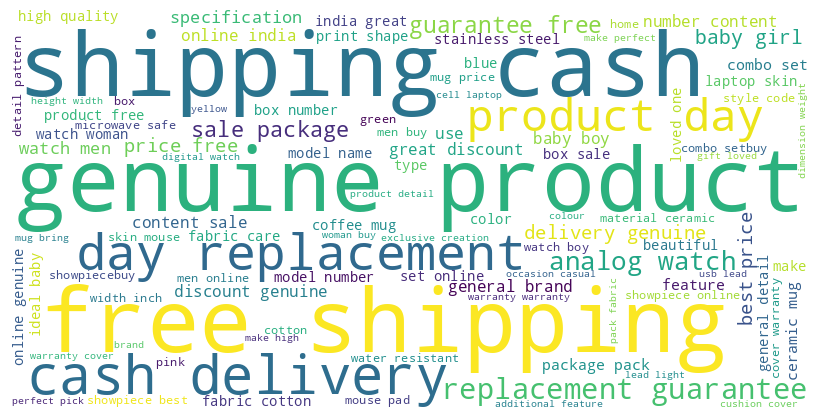

In [128]:
text_2 = " ".join(corpus_2)

fig = plt.figure(figsize=(8, 8), facecolor=None)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      stopwords=set(STOPWORDS),
                      min_font_size=10).generate(text_2)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# Extraction des caracteristiques

## Texts

In [129]:
def pca_dimensions(data, n=2):
  pca = PCA(n_components=n)
  pca.fit(data)
  return pca, pca.transform(data)

def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI, title):
    fig = plt.figure(figsize=(15,6))
    fig.suptitle(title)
    ax = fig.add_subplot(121)
    
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

In [130]:
def TFIDF(fit_data, transform_data, ngram = 1):
    tfidf_x = TfidfVectorizer(ngram_range = (ngram, ngram))
    tfidf_x.fit(fit_data)
    emb = tfidf_x.transform(transform_data).toarray()
    print("tf-idf avec", emb.shape[1], "features")
    return emb

#### TF-IDF

In [131]:
%%time
tf_idf_vectors = []

print("tf-idf appliquée au corpus_1: fit et transforme sur description")
corpus_1_tfidf_1gram = TFIDF(corpus_1, corpus_1, 1)
tf_idf_vectors.append(corpus_1_tfidf_1gram)
print("---"*10)

print("tf-idf appliquée au corpus_2: fit et transforme sur product_name + description")
corpus_2_tfidf_1gram = TFIDF(corpus_2, corpus_2, 1)
tf_idf_vectors.append(corpus_2_tfidf_1gram)
print("---"*10)

print("tf-idf appliquée au corpus_2: fit sur product_name et transforme sur product_name + description")
corpus_3_tfidf_1gram = TFIDF(data.product_name.tolist(), corpus_2, 1)
tf_idf_vectors.append(corpus_3_tfidf_1gram)
print("---"*10)

tf-idf appliquée au corpus_1: fit et transforme sur description
tf-idf avec 4079 features
------------------------------
tf-idf appliquée au corpus_2: fit et transforme sur product_name + description
tf-idf avec 4511 features
------------------------------
tf-idf appliquée au corpus_2: fit sur product_name et transforme sur product_name + description
tf-idf avec 2354 features
------------------------------
CPU times: user 884 ms, sys: 28.4 ms, total: 913 ms
Wall time: 905 ms


#### PCA: réduction de dimension

In [132]:
%%time
n_dim=0.9
pca_vectors = []

for i, vect in enumerate(tf_idf_vectors):
    pca, x_pca = pca_dimensions(vect, n=n_dim)
    pca_vectors.append(x_pca)
    print("--"*10)
    print(f"Reduction de dimension du vecteur N°{i+1}: Les {n_dim} dimensions capture {sum(pca.explained_variance_ratio_ * 100)} % de la variance")
    print("--"*10)

--------------------
Reduction de dimension du vecteur N°1: Les 0.9 dimensions capture 90.02063084928118 % de la variance
--------------------
--------------------
Reduction de dimension du vecteur N°2: Les 0.9 dimensions capture 90.01327642979352 % de la variance
--------------------
--------------------
Reduction de dimension du vecteur N°3: Les 0.9 dimensions capture 90.02739460944186 % de la variance
--------------------
CPU times: user 2min 44s, sys: 2.65 s, total: 2min 47s
Wall time: 16.1 s


#### Visialisation T-SNE: categorie réelle

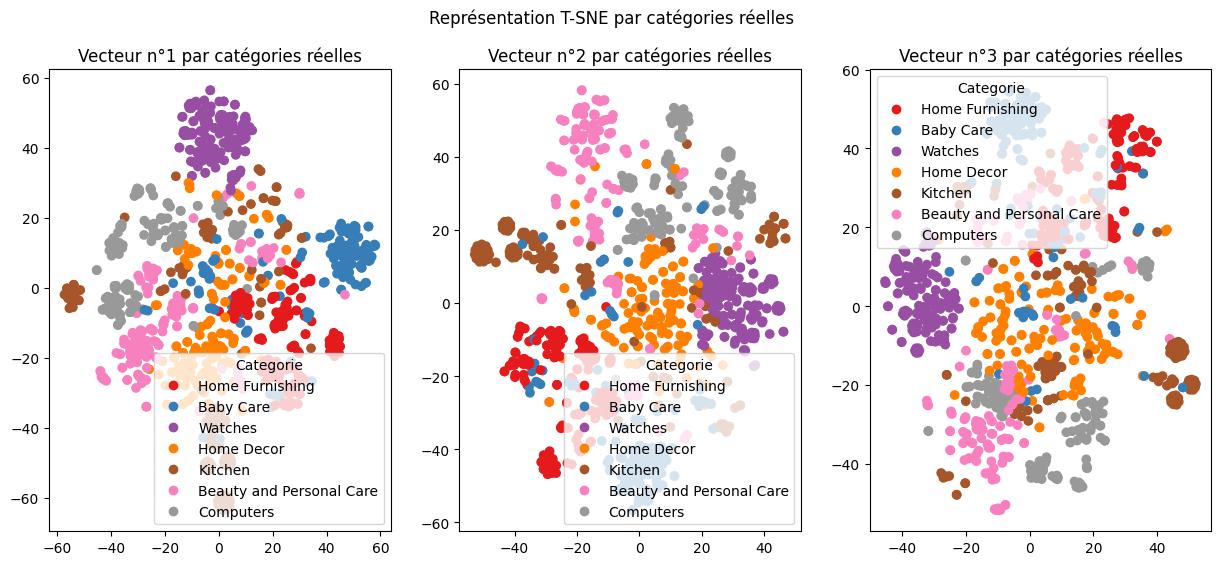

CPU times: user 5min 28s, sys: 1.7 ms, total: 5min 28s
Wall time: 52.7 s
Parser   : 172 ms


In [133]:
%%time
fig = plt.figure(figsize=(15,6))
colors, labels= pd.factorize(data.category)
tsne_data = []
for i, vec in enumerate(pca_vectors):
    tsne = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', learning_rate=200, random_state=42)
    X_tsne = tsne.fit_transform(vec)
    tsne_data.append(X_tsne)
    ax = fig.add_subplot(1,3,i+1)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=colors, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=labels.to_list(), loc="best", title="Categorie")
    ax.set_title(f"Vecteur n°{i+1} par catégories réelles")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

#### K-means

ARI :  0.4049 time :  1.65


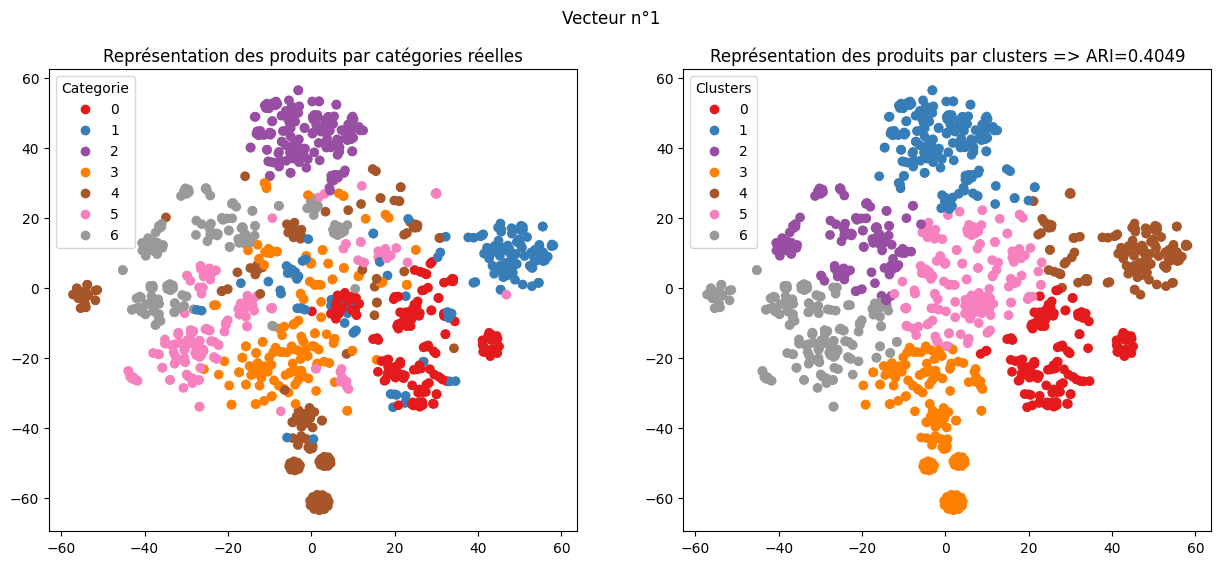

ARI :  0.5413 time :  2.32


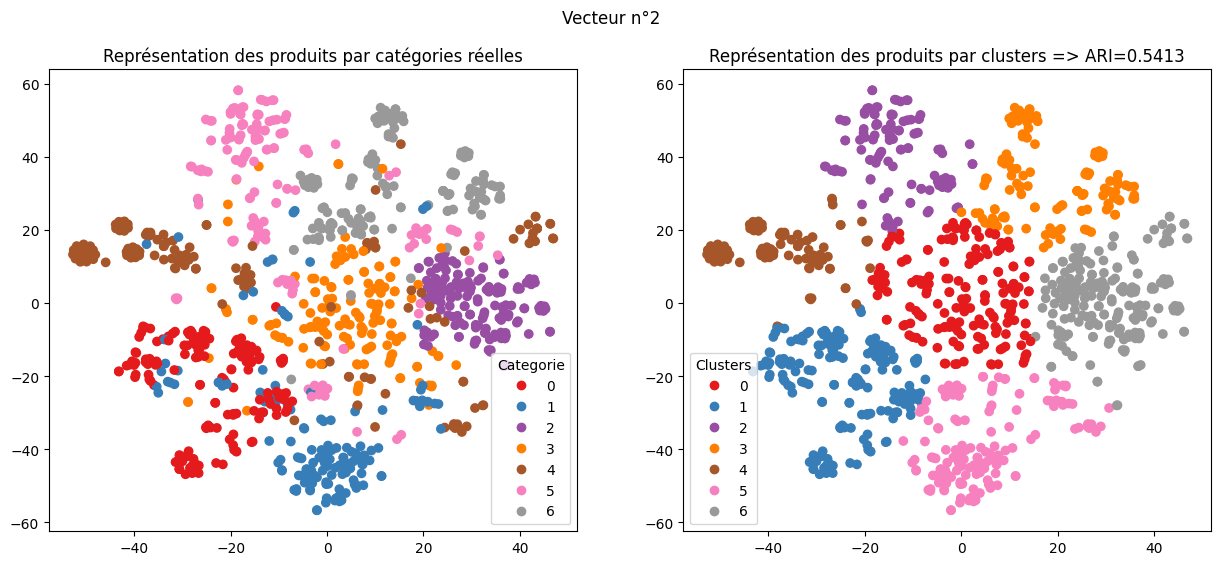

ARI :  0.3825 time :  1.57


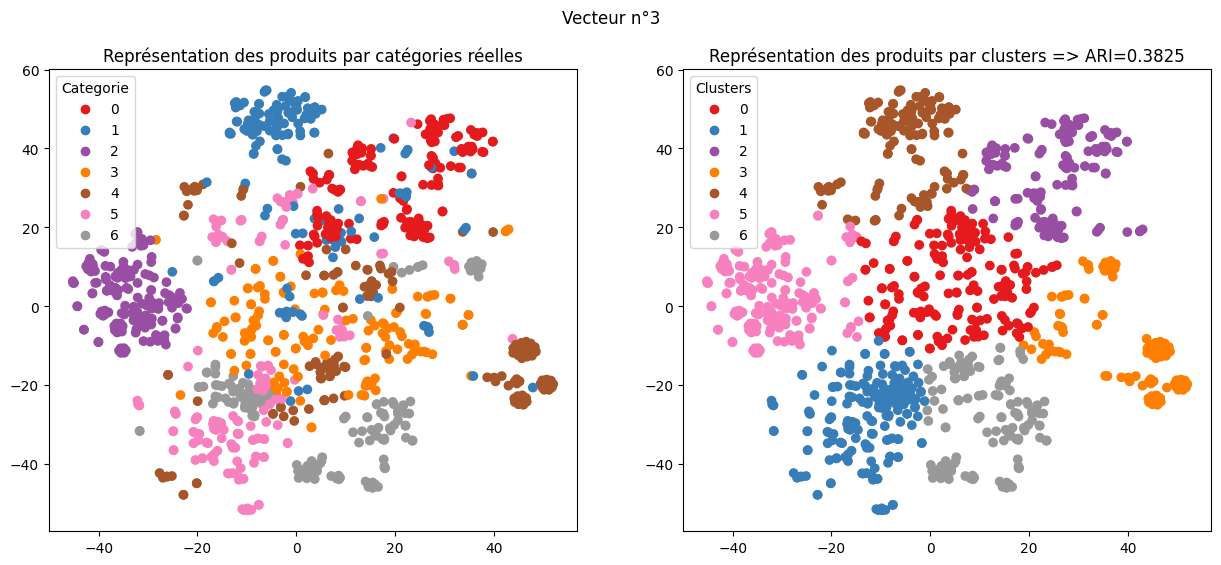

In [134]:
# Détermination des clusters à partir des données après Tsne

k=7
y_cat_num, labels= pd.factorize(data.category)

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
for i, X_tsne in enumerate(tsne_data):
    time1 = time.time()
    cls.fit(X_tsne)
    ARI = np.round(adjusted_rand_score(y_cat_num, cls.labels_),4)
    time2 = np.round(time.time() - time1, 2)
    print("ARI : ", ARI, "time : ", time2)
    tsne_visu_fct(X_tsne, y_cat_num, cls.labels_, ARI, f"Vecteur n°{i+1}")

Le résultat de notre algorithme k-means révèle que, pour les trois corpus étudiés, l’indice de Rand ajusté (ARI) se situe entre 0,4 et 0,54. Ce résultat quantitatif, associé à une visualisation graphique détaillée des catégories réelles, atteste de la faisabilité de classifier efficacement les biens de consommation en se fondant sur leur nom et/ou leur description.

## Images

### | SIFT

Nous allons prendre une image et appliquons la methode SIFT pour extraires les descripteurs

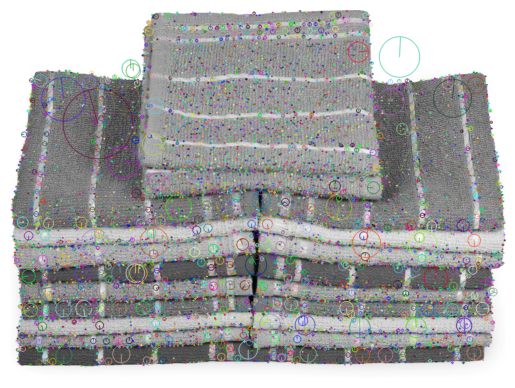

Descripteurs :  (7702, 128)

[[95. 24.  0. ...  0.  0.  0.]
 [19. 22. 10. ...  0.  0.  0.]
 [22.  4.  9. ...  0.  0.  1.]
 ...
 [46. 35.  0. ...  0.  0.  2.]
 [ 0.  8. 33. ...  0.  0.  0.]
 [49. 21.  3. ...  0.  0.  0.]]


In [135]:
idx = data.iloc[2].uniq_id
sift = cv.SIFT_create()
image = cv.imread(path+"Images/"+idx+'.jpg') 


gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY) # convert in gray

kp, des = sift.detectAndCompute(gray, None)
img=cv.drawKeypoints(gray, kp, image, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.axis('off')
plt.show()
print("Descripteurs : ", des.shape)
print()
print(des)

#### Créations des descripteurs

In [136]:
sample_df = data.copy()
ids = sample_df.uniq_id.to_list()

In [137]:
%%time
descriptors_list = []
sift = cv.SIFT_create()
for product_id in ids:
    # Chargement de l'image
    img_path = f"{path}Images/{product_id}.jpg"
    image = cv.imread(img_path)

    # Conversion en niveaux de gris
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Détection des keypoints et calcul des descripteurs SIFT
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    if descriptors is not None:
        descriptors_list.append(descriptors)
    else:
        print(f"Aucun descripteur trouvé pour l'image : {img_path}")

all_descriptors = np.vstack(descriptors_list)

print("Nombre de descripteurs : ", all_descriptors.shape)
print("---"*10)

Aucun descripteur trouvé pour l'image : ./data/Flipkart/Images/9743e6d1c9f3180483825fe4d2e97836.jpg


KeyboardInterrupt: 

In [138]:
all_descriptors[0]

array([  4.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,  11.,   0.,   0.,
         0.,   0.,   0.,   0.,   3.,   1.,   0.,   0.,   0.,   0.,   0.,
         0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  90.,
         0.,   0.,   0.,   1.,   1.,   0.,  14., 174.,  10.,   0.,   1.,
         6.,   1.,   0.,  76.,  58.,   3.,   2.,  24.,  64.,   2.,   0.,
        22.,   8.,   0.,   1.,  17.,  29.,   0.,   0.,   2., 124.,   2.,
         0.,   0.,   1.,   0.,   0.,  22., 174.,  55.,   1.,   7.,  15.,
         0.,   0.,  37.,  96.,  25.,  29.,  98., 122.,   0.,   0.,   4.,
        31.,  11.,  21.,  32.,  21.,   0.,   0.,  13., 123.,   0.,   0.,
         1.,   0.,   0.,   0.,  52., 174.,   4.,   0.,   2.,  24.,   3.,
         1., 142.,  81.,  18.,  11.,  41., 174.,  24.,   1.,  18.,  94.,
        22.,   7.,   6.,   9.,   3.,   0.,  20.], dtype=float32)

#### Clustering des descripteurs

In [139]:
%%time

k = int(round(np.sqrt(len(all_descriptors)),0))
print("Nombre de clusters estimés : ", k)
print("Création de",k, "clusters de descripteurs ...")

# Clustering
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
kmeans.fit(all_descriptors)
display(kmeans.labels_)

Nombre de clusters estimés :  2445
Création de 2445 clusters de descripteurs ...


array([ 513, 1938,    9, ...,  488,  454, 1431], dtype=int32)

CPU times: user 25min 44s, sys: 27.5 s, total: 26min 11s
Wall time: 5min 46s


#### Extraction des features images

In [140]:
%%time

def build_histogram(descriptors, num_clusters):
    n_desc = descriptors.shape[0]
    
    # Récupéreation des labels correspondant aux descripteurs de cette image
    image_labels = labels[start_index:start_index + n_desc]
    
    # Calcul de l'histogramme pour cette image
    hist, _ = np.histogram(image_labels, bins=np.arange(num_clusters+1))
    
    # Normalisation
    #hist = hist.astype("float32")
    #hist /= (hist.sum() + 1e-7)
    
    return hist


start_index = 0
hist_vectors=[]
labels = kmeans.labels_
for image_desc in descriptors_list:
    hist = build_histogram(image_desc, k)
    hist_vectors.append(hist)
    start_index += image_desc.shape[0]

im_features = np.asarray(hist_vectors)
print("Fetaures image:", im_features.shape)
print("Histogramme pour la première image :", hist_vectors[0])
print("---"*10)

Fetaures image: (440, 2445)
Histogramme pour la première image : [  4  10 631 ...  42   3  81]
------------------------------
CPU times: user 208 ms, sys: 4.59 ms, total: 212 ms
Wall time: 208 ms


#### Classification des images: Kmeans

##### Réduction des dimensions

In [141]:
%%time
# Réduction de dimension PCA
pca, X_pca = pca_dimensions(im_features, n=0.90)

# Réduction en deux dimensions via T-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_pca)
tsne_sift_df = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
tsne_sift_df['class'] = sample_df.category
tsne_sift_df['uniq_id'] = sample_df.uniq_id

CPU times: user 56.7 s, sys: 329 ms, total: 57 s
Wall time: 7.57 s


In [142]:
tsne_sift_df.head()

,tsne1,tsne2,class,uniq_id
0,6.948267,43.368492,Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7
1,6.849403,40.358788,Baby Care,7b72c92c2f6c40268628ec5f14c6d590
2,2.860826,29.624092,Baby Care,64d5d4a258243731dc7bbb1eef49ad74
3,8.587125,34.243938,Home Furnishing,d4684dcdc759dd9cdf41504698d737d8
4,7.071654,40.825886,Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7


##### kmeans

In [143]:
%%time
# Détermination des clusters à partir des données après Tsne
sample_df = sample_df.loc[sample_df.uniq_id!="9743e6d1c9f3180483825fe4d2e97836"]
k=7
y_cat_num, labels= pd.factorize(tsne_sift_df['class'])

cls = KMeans(n_clusters=k, random_state=42)
time1 = time.time()
cls.fit(X_tsne)
ARI = np.round(adjusted_rand_score(y_cat_num, cls.labels_), 4)
time2 = np.round(time.time() - time1, 2)
print("ARI : ", ARI, "time : ", time2)
tsne_sift_df['cluster'] = cls.labels_

ARI :  0.0615 time :  0.03
CPU times: user 120 ms, sys: 85.9 ms, total: 206 ms
Wall time: 276 ms


In [144]:
tsne_sift_df.head()

,tsne1,tsne2,class,uniq_id,cluster
0,6.948267,43.368492,Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7,6
1,6.849403,40.358788,Baby Care,7b72c92c2f6c40268628ec5f14c6d590,6
2,2.860826,29.624092,Baby Care,64d5d4a258243731dc7bbb1eef49ad74,3
3,8.587125,34.243938,Home Furnishing,d4684dcdc759dd9cdf41504698d737d8,6
4,7.071654,40.825886,Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7,6


##### Visualisation des clusters T-SNE

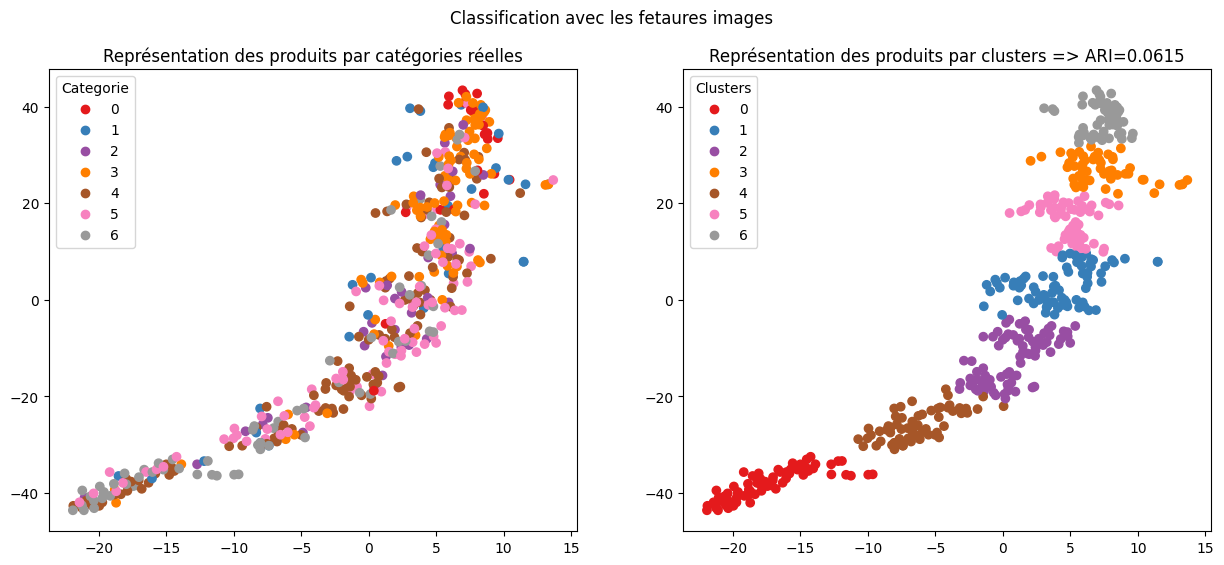

In [145]:
tsne_visu_fct(X_tsne, y_cat_num, cls.labels_, ARI, "Classification avec les fetaures images")

In [146]:
tsne_sift_df.groupby("cluster")["class"].value_counts().to_frame().reset_index()

,cluster,class,count
0,0,Computers,31
1,0,Kitchen,20
2,0,Beauty and Personal Care,9
3,0,Baby Care,3
4,0,Home Decor,3
5,0,Watches,2
6,1,Kitchen,22
7,1,Beauty and Personal Care,18
8,1,Home Decor,13
9,1,Watches,9


In [147]:
from sklearn import metrics
conf_mat = metrics.confusion_matrix(y_cat_num, cls.labels_)
print(conf_mat)

[[ 0  0  2  4  0  3 13]
 [ 3  7  1  9  4  2  5]
 [ 2  9 10  3  6  4  2]
 [ 3 13  4 18  4 20 22]
 [20 22 29 11 18 12  2]
 [ 9 18 22  5 18 11  3]
 [31  5 10  2 12  5  2]]


In [148]:
print(metrics.classification_report(y_cat_num, cls.labels_))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.09      0.23      0.13        31
           2       0.13      0.28      0.18        36
           3       0.35      0.21      0.26        84
           4       0.29      0.16      0.20       114
           5       0.19      0.13      0.15        86
           6       0.04      0.03      0.03        67

    accuracy                           0.15       440
   macro avg       0.16      0.15      0.14       440
weighted avg       0.20      0.15      0.16       440



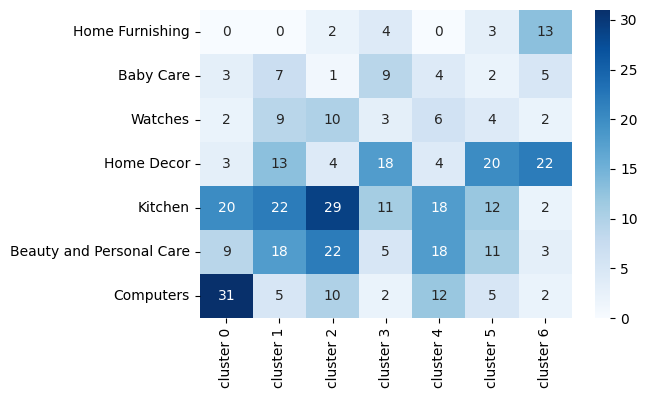

In [149]:
df_cm = pd.DataFrame(conf_mat, index = labels,
                  columns = [f"cluster {i}" for i in "0123456"])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

In [150]:
ids = tsne_sift_df.loc[(tsne_sift_df['class']=='Kitchen') & (tsne_sift_df.cluster==6)].index.to_list()
ids = tsne_sift_df.loc[(tsne_sift_df.cluster==6)].index.to_list()
"""for id in ids:
    tsne_sift_df.iloc[id]
    im_id = tsne_sift_df.iloc[id].uniq_id
    fig = plt.figure(figsize = (8, 5))
    filename = f"{path}Images/{im_id}.jpg"
    image = imread(filename)
    plt.imshow(image)
plt.show()"""

'for id in ids:\n    tsne_sift_df.iloc[id]\n    im_id = tsne_sift_df.iloc[id].uniq_id\n    fig = plt.figure(figsize = (8, 5))\n    filename = f"{path}Images/{im_id}.jpg"\n    image = imread(filename)\n    plt.imshow(image)\nplt.show()'

In [151]:
data[['uniq_id', 'category']].to_csv(f"{path}cleaned_data.csv", index=False)

In [152]:
end_time = time.time()
print(f"Execution time={end_time-init_time} seconds")

Execution time=990.8214147090912 seconds
